# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA (Exploratory Data Analysis) and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [93]:
import os, zipfile, glob #for working with files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import set_config


# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [94]:
# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)
zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

In [95]:
csv_files = glob.glob(f"{EXTRACT_DIR}/**/*.csv", recursive=True)

print(csv_files)

['heart_ds/dataset_heart.csv']


In [96]:
# TODO: list CSV files under EXTRACT_DIR
csv_path = csv_files[0]  # set to the CSV you choose

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# TODO: inspect df
print(df.shape)

print(df.info()) #shows data types

print(df.describe()) #shows statistics


print(df.head())




(270, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major ves

In [97]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [98]:
# TODO: identify target column
target = 'heart disease'    # 'target'

# TODO: split features and target
X = df.drop(columns=['heart disease'])  # df.drop(columns=[...])
y = df['heart disease']  # df[...]


# TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
# Hint: train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

### Basic visual checks

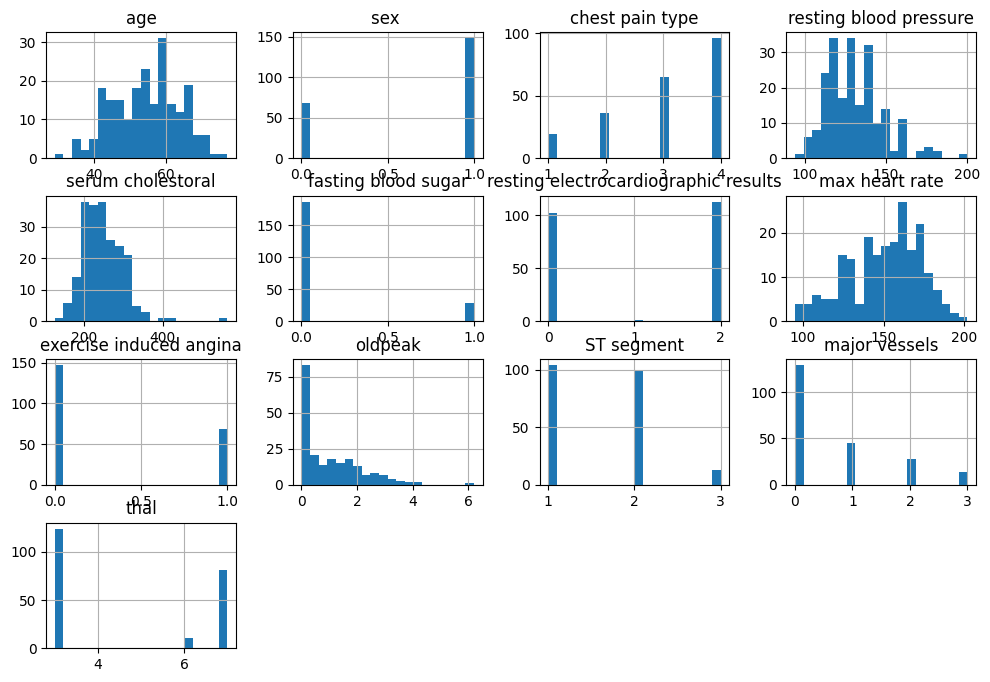

In [99]:
# TODO: pick a few numeric columns and plot histograms
X_train.hist(
    figsize=(12, 8),
    bins=20
)

plt.show()






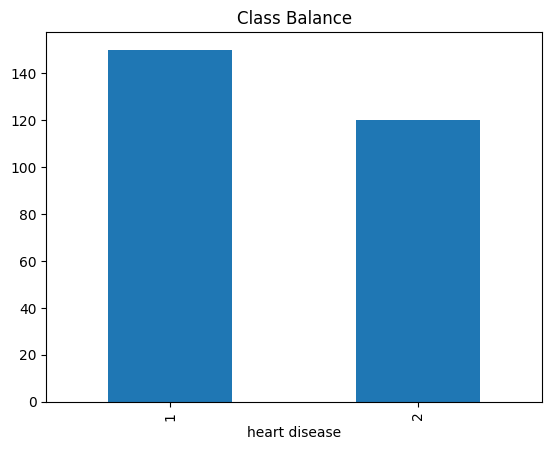

In [100]:
# TODO: plot class balance as a bar chart

y.value_counts().plot(kind='bar')

plt.title("Class Balance")

plt.show()

## Preprocessing pipeline

In [101]:
num_cols = X_train.columns.tolist()  # list of numeric columns - all columns
cat_cols = []   # list of object, category, or bool columns, no categorial columns in this case

# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ]
)


## Helper - evaluation function

In [102]:
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test) # model.predict(...)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }
    print(name, metrics)

    # TODO: confusion matrix plot - confusion matrix shows where exactly a model made mistakes
    # Hint: confusion_matrix(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred
        )
    plt.show()

    # TODO: ROC curve (Receiver Operating Characteristic) if model has predict_proba (can calculate probability) - ROC curve shows the quality of the model
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1] # probabiity of the class 1 (desease)
        # automatically detect positive class
        pos_label = max(y_test)
        fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=pos_label) #False Positive Rate, True Positive Rate, value is returned but not needed
        plt.plot(fpr, tpr)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")

        plt.show()
    return metrics


## Exercise 2 - Logistic Regression without Grid Search

Logistic Regression {'accuracy': 0.8518518518518519, 'precision': 0.9230769230769231, 'recall': 0.8, 'f1': 0.8571428571428571}


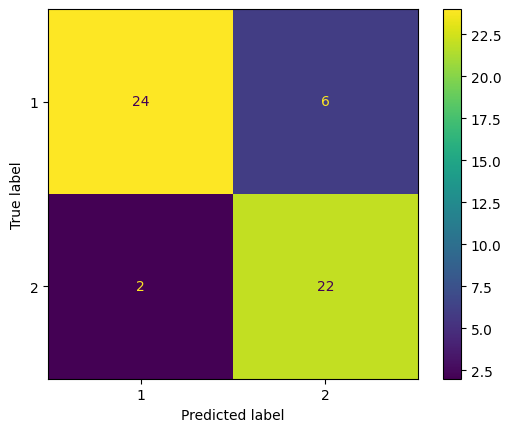

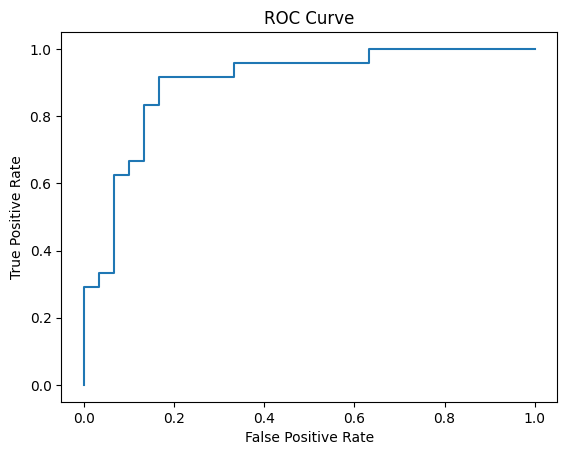

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'sex ',
                                                   'chest pain type',
                                                   'resting blood pressure',
                                                   'serum cholestoral',
                                                   'fasting blood sugar',
                                                   'resting '
                                                   'electrocardiographic '
                                                   'results',
                                                   'max heart rate',
                                                   'exercise induced angina',
                                                   'oldpeak', 'ST segment',
                                                   'major vessels',
                                                   'thal'])])),
                ('model',
                 LogisticRegression(random_state=42, solver='liblinear'))])

In [103]:
# TODO: create a Pipeline with your preprocessor (StandardScaler) and LogisticRegression (model)
# Hint: solver 'liblinear' is fine, increase max_iter if needed
# If we define only solver, it would mean that other parameters are set to their default values:

# LogisticRegression(
#     penalty='l2',
#     C=1.0,
#     solver='liblinear',
#     max_iter=100,
#     ...
# )
pipe_lr = Pipeline([
    ('preprocessor', pre),
    ('model', LogisticRegression(
        solver='liblinear', #algorithm of training
        random_state=RANDOM_STATE
    ))
])

# TODO: fit on training data
# pipe_lr.fit(...)
pipe_lr.fit(X_train, y_train) #train your model on training data

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report(
    "Logistic Regression",
    pipe_lr,
    X_test,
    y_test
)

set_config(display='diagram')
pipe_lr

In [104]:
print(type(pipe_lr))
print(hasattr(pipe_lr, "predict"))
print(hasattr(pipe_lr, "predict_proba"))
print(hasattr(pipe_lr, "fit"))

<class 'sklearn.pipeline.Pipeline'>
True
True
True


In [105]:
pipe_lr.predict_proba(X_test)

array([[0.9719206 , 0.0280794 ],
       [0.84250673, 0.15749327],
       [0.93665158, 0.06334842],
       [0.09525431, 0.90474569],
       [0.5949962 , 0.4050038 ],
       [0.92548201, 0.07451799],
       [0.92032105, 0.07967895],
       [0.01353084, 0.98646916],
       [0.40687128, 0.59312872],
       [0.36532448, 0.63467552],
       [0.8300612 , 0.1699388 ],
       [0.3069684 , 0.6930316 ],
       [0.89099456, 0.10900544],
       [0.01988893, 0.98011107],
       [0.3567943 , 0.6432057 ],
       [0.06041957, 0.93958043],
       [0.99132863, 0.00867137],
       [0.01943291, 0.98056709],
       [0.98003822, 0.01996178],
       [0.08423211, 0.91576789],
       [0.90569929, 0.09430071],
       [0.02161251, 0.97838749],
       [0.96291078, 0.03708922],
       [0.72335351, 0.27664649],
       [0.88184915, 0.11815085],
       [0.01174957, 0.98825043],
       [0.88757344, 0.11242656],
       [0.73119487, 0.26880513],
       [0.95399371, 0.04600629],
       [0.01604091, 0.98395909],
       [0.

## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.01, 'lr__penalty': 'l2'}
LR grid {'accuracy': 0.8333333333333334, 'precision': 0.8888888888888888, 'recall': 0.8, 'f1': 0.8421052631578947}


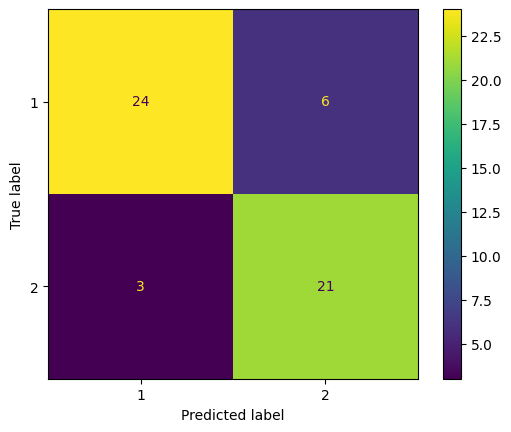

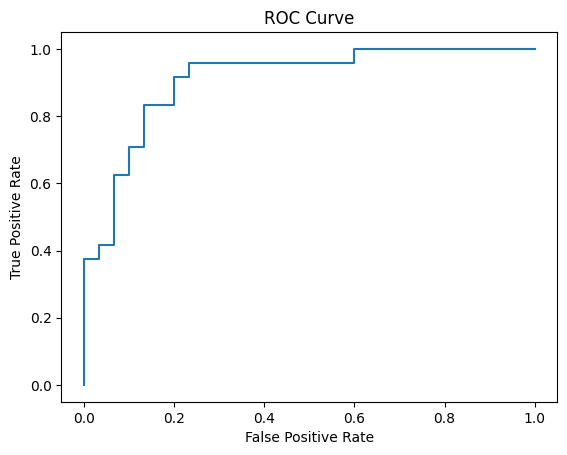

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'sex ',
                                                   'chest pain type',
                                                   'resting blood pressure',
                                                   'serum cholestoral',
                                                   'fasting blood sugar',
                                                   'resting '
                                                   'electrocardiographic '
                                                   'results',
                                                   'max heart rate',
                                                   'exercise induced angina',
                                                   'oldpeak', 'ST segment',
                                                   'major vessels',
                                                   'thal'])])),
                ('lr',
                 LogisticRegression(random_state=42, solver='liblinear'))])

In [106]:
# TODO: build a Pipeline same as above
# pipe_lr_cv - a model to set up and train
pipe_lr_cv = Pipeline([
    ('preprocessor', pre),
    ('lr', LogisticRegression(
        solver='liblinear',
        random_state=RANDOM_STATE
    ))
])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values (С defines how complex a model can become while doing Grid Search,
# C = 0.01 means model should be simple, C = 100 means that there are no limitations, the model can be adjusted to the data, but there will be a risk of overfitting).
# penalty is a penalty for too complex model. Penalty='l1' is bery agressive penalty, that will through away some parameters
#'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
}

# TODO: GridSearchCV with cv=5 (number of cross validations) and scoring='f1'
grid_lr = GridSearchCV(
    pipe_lr_cv,
    param_grid,
    cv=5,
    scoring='f1'
)
grid_lr.fit(X_train, y_train) #pipe_lr.fit in a previous task trains one model, grid_lr.fit - 50 models (5 options for C, 2 - for penalties, 5 - number of cross validations, so 5x2x5=50)

print('Best params:', grid_lr.best_params_) # '_' appears to show that the attribute will appear only after training
best_lr = grid_lr.best_estimator_ #best model
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)

set_config(display='diagram')
pipe_lr_cv


## Exercise 4 - SVM without Grid Search

SVM no grid {'accuracy': 0.8148148148148148, 'precision': 0.8571428571428571, 'recall': 0.8, 'f1': 0.8275862068965517}


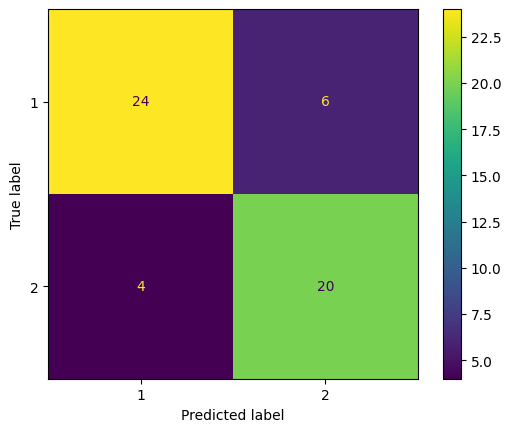

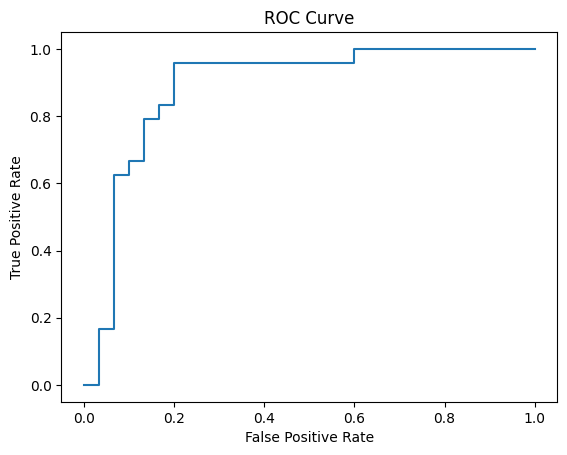

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'sex ',
                                                   'chest pain type',
                                                   'resting blood pressure',
                                                   'serum cholestoral',
                                                   'fasting blood sugar',
                                                   'resting '
                                                   'electrocardiographic '
                                                   'results',
                                                   'max heart rate',
                                                   'exercise induced angina',
                                                   'oldpeak', 'ST segment',
                                                   'major vessels',
                                                   'thal'])])),
                ('svm', SVC(probability=True))])

In [107]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' (curve line as opposed to kernel = 'linear' - straight line) with C=1.0 and gamma='scale'
pipe_svm = Pipeline([
    ('preprocessor', pre),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True #for ROC curve in eval_and_report
    ))
])
pipe_svm.fit(X_train, y_train)

svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)

set_config(display='diagram')
pipe_svm


The Logistic Regression model achieved the best performance on the test set with an F1-score of 0.857.

Logistic Regression with Grid Search achieved a slightly lower F1-score of 0.842.

The SVM model achieved an F1-score of 0.828, making it the weakest of the three evaluated models on this dataset.

## Exercise 5 - SVM with Grid Search

Best params: {'svm__C': 0.01, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
SVM grid {'accuracy': 0.8518518518518519, 'precision': 0.8928571428571429, 'recall': 0.8333333333333334, 'f1': 0.8620689655172413}


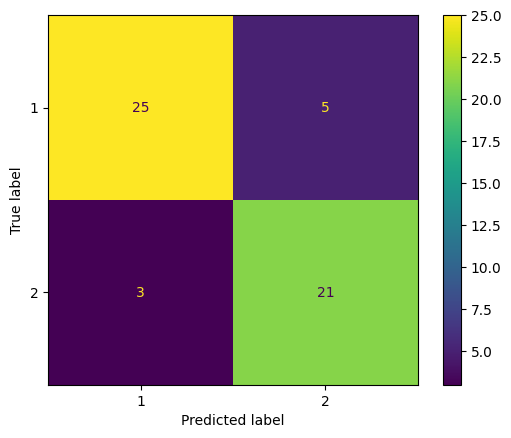

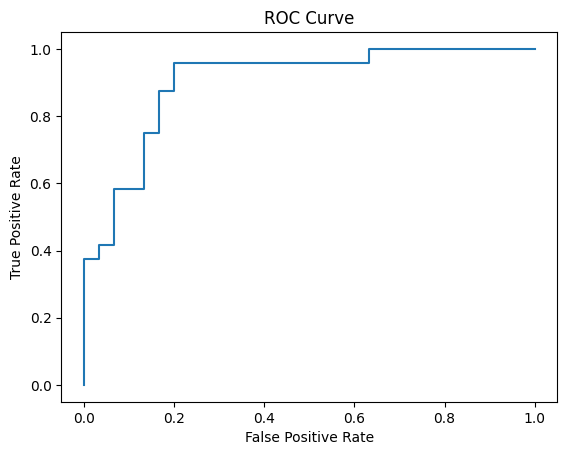

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'sex ',
                                                   'chest pain type',
                                                   'resting blood pressure',
                                                   'serum cholestoral',
                                                   'fasting blood sugar',
                                                   'resting '
                                                   'electrocardiographic '
                                                   'results',
                                                   'max heart rate',
                                                   'exercise induced angina',
                                                   'oldpeak', 'ST segment',
                                                   'major vessels',
                                                   'thal'])])),
                ('svm', SVC(probability=True))])

In [108]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline([
    ('preprocessor', pre),
    ('svm', SVC(
        probability=True
    ))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
# 2 × 5 × 2 = 20 combinations. With CV=5 this model will do 100 trainings
svm_param_grid = {
    'svm__kernel': ['rbf','linear'],
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__gamma': ['scale','auto'],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(
    pipe_svm_cv,
    svm_param_grid,
    cv=5,
    scoring='f1'
)
grid_svm.fit(X_train, y_train)

print("Best params:", grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)

set_config(display='diagram')
pipe_svm_cv


SVM with Grid Search achieved the highest F1 score (0.862), making it the best-performing model among the tested approaches.

## Exercise 6 - XGBoost without Grid Search

[0 1]
XGB no grid {'accuracy': 0.7962962962962963, 'precision': 0.7407407407407407, 'recall': 0.8333333333333334, 'f1': 0.7843137254901961}


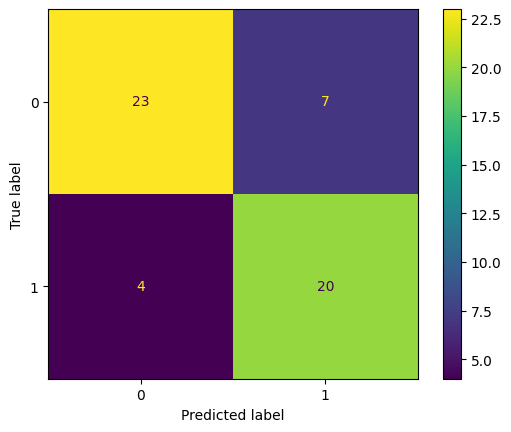

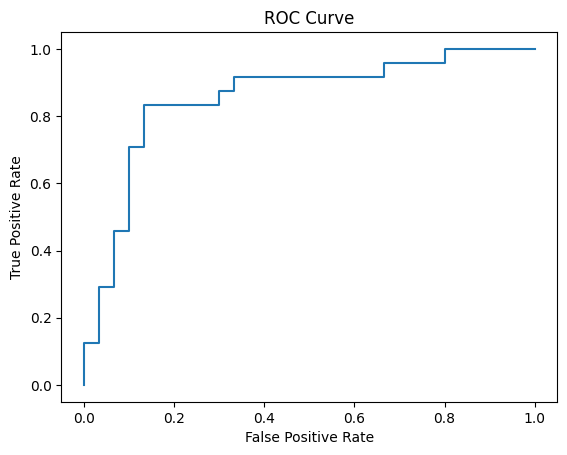

In [111]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators (how many trees to build) around 300, learning_rate 0.1, max_depth 3 to 5
# convert labels from 1/2 to 0/1 for XGBoost
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

print(y_train_xgb.unique())

pipe_xgb = Pipeline([
    ('preprocessor', pre),
    ('xgb', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])
pipe_xgb.fit(X_train, y_train_xgb)
xgb_no_metrics = eval_and_report(
    'XGB no grid',
    pipe_xgb,
    X_test,
    y_test_xgb
)



In [112]:
set_config(display='diagram')

pipe_xgb

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'sex ',
                                                   'chest pain type',
                                                   'resting blood pressure',
                                                   'serum cholestoral',
                                                   'fasting blood sugar',
                                                   'resting '
                                                   'electrocardiographic '
                                                   'results',
                                                   'max heart rate',
                                                   'exercise induced angina',
                                                   'oldpeak', 'ST segment',
                                                   'major vessels',
                                                   'thal'])])),
                ('xgb',
                 XGBClassifier(base_score=None, boost...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

## Exercise 7 - XGBoost with Grid Search

Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.3, 'xgb__max_depth': 5, 'xgb__n_estimators': 500, 'xgb__subsample': 0.8}
XGB grid {'accuracy': 0.8148148148148148, 'precision': 0.75, 'recall': 0.875, 'f1': 0.8076923076923077}


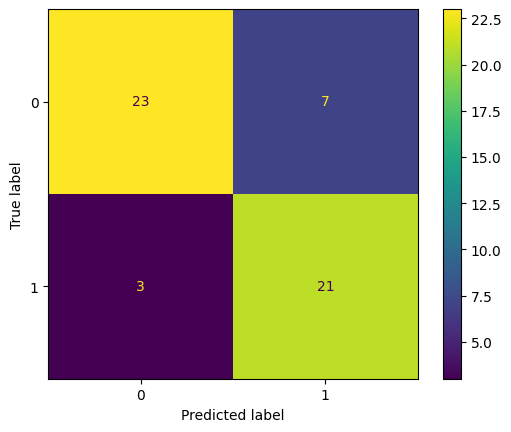

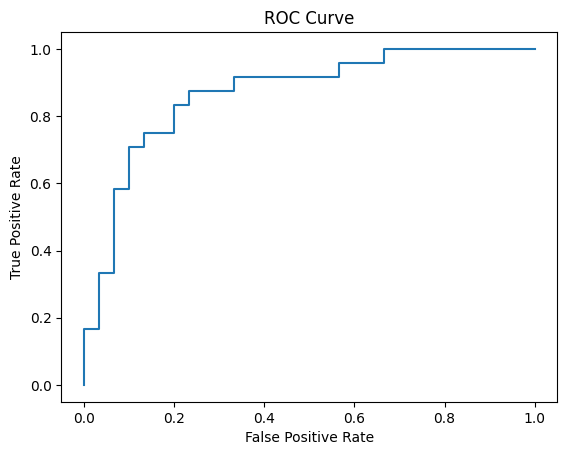

In [118]:
# TODO: Pipeline with XGBClassifier

pipe_xgb_cv = Pipeline([
    ('preprocessor', pre),
    ('xgb', XGBClassifier(
        random_state=RANDOM_STATE
    ))
])

# TODO: define a reasonable param_grid

xgb_param_grid = {
    'xgb__n_estimators': [100, 300, 500],
    'xgb__learning_rate': [0.01, 0.1, 0.3],
    'xgb__max_depth': [3, 5, 7],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

# TODO: GridSearchCV, fit, evaluate best estimator

grid_xgb = GridSearchCV(
    pipe_xgb_cv,
    xgb_param_grid,
    cv=5,
    scoring='f1'
)

# XGBoost expects classes 0 and 1
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

grid_xgb.fit(X_train, y_train_xgb)

print("Best params:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

xgb_gs_metrics = eval_and_report(
    'XGB grid',
    best_xgb,
    X_test,
    y_test_xgb
)

## Compare models

In [119]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')


summary = {}
# summary['LR no grid'] = lr_no_gs_metrics
# ... add others you computed ...

summary
summary['LR no grid'] = lr_no_gs_metrics
summary['LR grid'] = lr_gs_metrics

summary['SVM no grid'] = svm_no_metrics
summary['SVM grid'] = svm_gs_metrics

summary['XGB no grid'] = xgb_no_metrics
summary['XGB grid'] = xgb_gs_metrics

summary_df = pd.DataFrame.from_dict(
    summary,
    orient='index'
)

summary_df


,accuracy,precision,recall,f1
LR no grid,0.851852,0.923077,0.800000,0.857143
LR grid,0.833333,0.888889,0.800000,0.842105
SVM no grid,0.814815,0.857143,0.800000,0.827586
SVM grid,0.851852,0.892857,0.833333,0.862069
XGB no grid,0.796296,0.740741,0.833333,0.784314
XGB grid,0.814815,0.750000,0.875000,0.807692


Several models were trained and compared using Accuracy, Precision, Recall and F1 score.

Logistic Regression achieved strong baseline performance with F1 ≈ 0.86.

Grid Search improved the SVM model and it achieved the best overall result with F1 ≈ 0.862.

XGBoost improved after hyperparameter tuning but still underperformed compared to Logistic Regression and SVM on this dataset.

Therefore, the best model for this dataset is the Grid Search optimized SVM classifier.